# Exploratory Data Analysis with PySpark

This notebook performs an exploratory data analysis on the YouTube Comment Sentiment dataset.

The goal is to demonstrate how PySpark can be used for large-scale data processing, including:

- Data ingestion;
- RDD-based preprocessing;
- DataFrame-based analysis;
- Data cleaning;
- Spark SQL queries;
- RDD transformations;
- Business-oriented insights for sentiment analysis.

The dataset used in this project is `AmaanP314/youtube-comment-sentiment` from Hugging Face.

All non-big-data-safe operations carry a `(!) BIG-DATA NOTE` comment explaining the risk and why it is acceptable in context.

## 1. Environment Setup

In [1]:
import os
import sys
from pathlib import Path

from datasets import load_dataset, load_from_disk

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

sys.path.insert(0, str(Path("../src").resolve()))
from utils import (
    build_clean_comments_schema,
    create_spark_session,
    prepare_comment_record,
)
from config import (
    DATASET_ID, SAVE_DIR, PARQUET_PATH, PROCESSED_PARQUET_PATH, STOP_WORDS
)

spark = create_spark_session(app_name="youtube-comment-sentiment-eda")
sc = spark.sparkContext

print("Setup complete.")
print("Spark version:", spark.version)
print("Default parallelism:", sc.defaultParallelism)


/opt/anaconda3/envs/general/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/04 23:03:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setup complete.
Spark version: 4.1.2
Default parallelism: 10


In [2]:
# EDA presentation plot setup
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "font.size": 10,
    "axes.titleweight": "bold",
})

SENTIMENT_COLORS = {
    "Positive": "#2E7D32",
    "Neutral": "#607D8B",
    "Negative": "#C62828",
}


def show_eda_plot(fig):
    plt.show()

## 2. Dataset Ingestion

Download dataset from Hugging Face and convert to Parquet

In [3]:
if SAVE_DIR.exists() and any(SAVE_DIR.iterdir()):
    ds = load_from_disk(str(SAVE_DIR))
    print(f"Dataset already downloaded at: {SAVE_DIR}")
else:
    SAVE_DIR.parent.mkdir(parents=True, exist_ok=True)
    ds = load_dataset(DATASET_ID)
    ds.save_to_disk(str(SAVE_DIR))
    print(f"Downloaded and saved dataset to: {SAVE_DIR}")

print(ds)

hf_train = ds["train"] if "train" in ds else ds

if not PARQUET_PATH.exists():
    hf_train.to_parquet(str(PARQUET_PATH))
    print(f"Parquet file created at: {PARQUET_PATH}")
else:
    print(f"Parquet file already exists at: {PARQUET_PATH}")

spark_df = spark.read.parquet(str(PARQUET_PATH))

spark_df = spark_df.cache()

print("Rows:", spark_df.count())
print("Columns:", len(spark_df.columns))

spark_df.printSchema()
spark_df.show(5, truncate=False)

print(f"Total columns: {len(spark_df.columns)}")
print(f"Total rows in dataset: {spark_df.count()}")

Dataset already downloaded at: /Users/pedro/Documents/DSAA/2semester/BDA/Project/Big-Data-Analyitics-Project/data/youtube-comment-sentiment
DatasetDict({
    train: Dataset({
        features: ['CommentID', 'VideoID', 'VideoTitle', 'AuthorName', 'AuthorChannelID', 'CommentText', 'Sentiment', 'Likes', 'Replies', 'PublishedAt', 'CountryCode', 'CategoryID'],
        num_rows: 1032225
    })
})
Parquet file already exists at: /Users/pedro/Documents/DSAA/2semester/BDA/Project/Big-Data-Analyitics-Project/data/youtube-comment-sentiment/train.parquet


Rows: 1032225
Columns: 12
root
 |-- CommentID: string (nullable = true)
 |-- VideoID: string (nullable = true)
 |-- VideoTitle: string (nullable = true)
 |-- AuthorName: string (nullable = true)
 |-- AuthorChannelID: string (nullable = true)
 |-- CommentText: string (nullable = true)
 |-- Sentiment: string (nullable = true)
 |-- Likes: long (nullable = true)
 |-- Replies: long (nullable = true)
 |-- PublishedAt: string (nullable = true)
 |-- CountryCode: string (nullable = true)
 |-- CategoryID: long (nullable = true)

+--------------------------+-----------+----------------------------------------------------------------------------------------------------+----------------------+------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 3. Initial Exploration

Inspect dataset structure, schema, and identify basic characteristics.

In [4]:
spark_df.show(10, truncate=80)

+--------------------------+-----------+--------------------------------------------------------------------------------+----------------------+------------------------+--------------------------------------------------------------------------------+---------+-----+-------+-------------------+-----------+----------+
|                 CommentID|    VideoID|                                                                      VideoTitle|            AuthorName|         AuthorChannelID|                                                                     CommentText|Sentiment|Likes|Replies|        PublishedAt|CountryCode|CategoryID|
+--------------------------+-----------+--------------------------------------------------------------------------------+----------------------+------------------------+--------------------------------------------------------------------------------+---------+-----+-------+-------------------+-----------+----------+
|UgyRjrEdJIPrf68uND14AaABAg|mcY4M9gjtsI|      

## 4. Data Quality Checks

Analyze missing values and duplicates to assess data quality before cleaning.

In [5]:
missing_values_df = spark_df.select([
    F.count(
        F.when(
            F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""),
            c
        )
    ).alias(c)
    for c in spark_df.columns
])

missing_values_df.show(truncate=False)

+---------+-------+----------+----------+---------------+-----------+---------+-----+-------+-----------+-----------+----------+
|CommentID|VideoID|VideoTitle|AuthorName|AuthorChannelID|CommentText|Sentiment|Likes|Replies|PublishedAt|CountryCode|CategoryID|
+---------+-------+----------+----------+---------------+-----------+---------+-----+-------+-----------+-----------+----------+
|0        |0      |0         |631       |0              |161        |0        |0    |0      |0          |0          |0         |
+---------+-------+----------+----------+---------------+-----------+---------+-----+-------+-----------+-----------+----------+



Which column has the most missing or empty values?

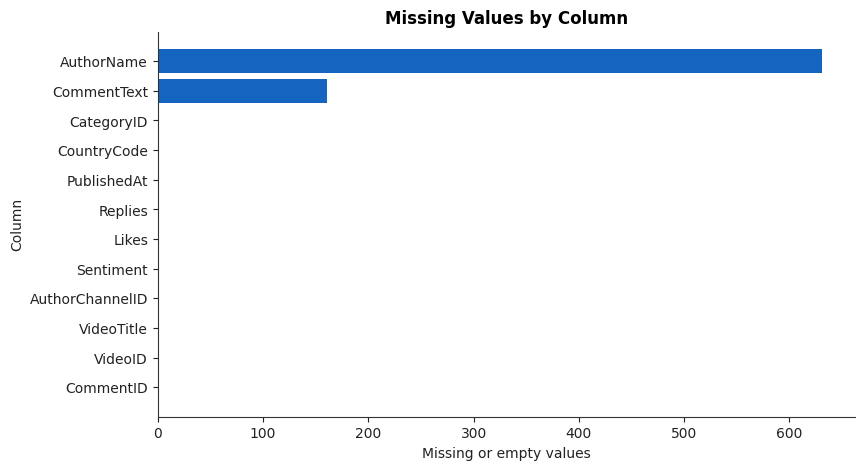

In [6]:
# (!) BIG-DATA NOTE: .toPandas() collects data from all Spark executors to the
# driver. This is ONLY safe when the upstream result is guaranteed to be small.
missing_plot_df = (
    missing_values_df
    .toPandas()
    .T
    .reset_index()
)
missing_plot_df.columns = ["column", "missing_values"]
missing_plot_df = missing_plot_df.sort_values("missing_values", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(missing_plot_df["column"], missing_plot_df["missing_values"], color="#1565C0")
ax.set_title("Missing Values by Column")
ax.set_xlabel("Missing or empty values")
ax.set_ylabel("Column")
ax.spines[["top", "right"]].set_visible(False)
show_eda_plot(fig)

## 5. RDD Preprocessing

**Why RDDs here?**  
`prepare_comment_record` reads and mutates multiple fields simultaneously (type coercion, text cleaning, and three derived features) in a single
Python function call. While individual steps are expressible as native Spark functions, bundling them into one RDD `map` avoids re-scanning
the partition for each `withColumn` and keeps the preprocessing logic in plain, testable Python - reused without adaptation to UDFs.

RDDs are preferred over DataFrames when transformation logic spans multiple fields atomically and needs to remain decoupled from Spark's column expression DSL.

In [7]:
# DataFrame to RDD
rawCommentsRDD = spark_df.rdd
print("Raw RDD partitions:", rawCommentsRDD.getNumPartitions())
print("Raw RDD first row:")
print(rawCommentsRDD.take(1)[0])

# map transformation: apply row-level preprocessing functions from utils.py
preparedCommentsRDD = rawCommentsRDD.map(prepare_comment_record)

# filter transformation: remove empty comments after cleaning
cleanCommentsRDD = preparedCommentsRDD.filter(lambda row: row["clean_text"] != "")

# cache because this cleaned RDD is reused for counts, preview, and DataFrame creation
cleanCommentsRDD.cache()

print("Original rows:", rawCommentsRDD.count())
print("Clean rows after RDD preprocessing:", cleanCommentsRDD.count())
print("Clean RDD partitions:", cleanCommentsRDD.getNumPartitions())
print("Clean RDD preview:")
for row in cleanCommentsRDD.take(3):
    print(row)

# Create an explicit schema 
clean_schema = build_clean_comments_schema(spark_df.schema)
clean_df = spark.createDataFrame(cleanCommentsRDD, schema=clean_schema).cache()

clean_df.select(
    "CommentText",
    "clean_text",
    "comment_word_count",
    "engagement_total",
    "engagement_level",
    "CountryCode"
).show(10, truncate=120)


Raw RDD partitions: 10
Raw RDD first row:


Row(CommentID='UgyRjrEdJIPrf68uND14AaABAg', VideoID='mcY4M9gjtsI', VideoTitle='They killed my friend.#tales #movie #shorts', AuthorName='@OneWhoWandered', AuthorChannelID='UC_-UEXaBL1dqqUPGkDll49A', CommentText='Anyone know what movie this is?', Sentiment='Neutral', Likes=0, Replies=2, PublishedAt='2025-01-15 00:54:55', CountryCode='NZ', CategoryID=1)


Original rows: 1032225


26/06/04 23:03:23 WARN MemoryStore: Not enough space to cache rdd_57_7 in memory! (computed 42.5 MiB so far)
26/06/04 23:03:23 WARN BlockManager: Putting block rdd_57_7 failed
26/06/04 23:03:23 WARN BlockManager: Block rdd_57_7 could not be removed as it was not found on disk or in memory
26/06/04 23:03:24 WARN MemoryStore: Not enough space to cache rdd_57_4 in memory! (computed 64.4 MiB so far)
26/06/04 23:03:24 WARN BlockManager: Putting block rdd_57_4 failed
26/06/04 23:03:24 WARN BlockManager: Block rdd_57_4 could not be removed as it was not found on disk or in memory


Clean rows after RDD preprocessing: 1015995
Clean RDD partitions: 10
Clean RDD preview:


Row(CommentID='UgyRjrEdJIPrf68uND14AaABAg', VideoID='mcY4M9gjtsI', VideoTitle='They killed my friend.#tales #movie #shorts', AuthorName='@OneWhoWandered', AuthorChannelID='UC_-UEXaBL1dqqUPGkDll49A', CommentText='Anyone know what movie this is?', Sentiment='Neutral', Likes=0, Replies=2, PublishedAt='2025-01-15 00:54:55', CountryCode='NZ', CategoryID=1, clean_text='anyone know what movie this is', comment_word_count=6, comment_char_count=30, engagement_total=2, engagement_level='low')
Row(CommentID='UgxXxEIySAwnMNw8D7N4AaABAg', VideoID='2vuXcw9SZbA', VideoTitle='Man Utd conceding first penalty at home in years and this is their reaction 😭', AuthorName='@chiefvon3068', AuthorChannelID='UCZ1LcZESjYqzaQRhjdZJFwg', CommentText="The fact they're holding each other back while equally being most aggressive 😂😂", Sentiment='Positive', Likes=0, Replies=0, PublishedAt='2025-01-13 23:51:46', CountryCode='AU', CategoryID=17, clean_text='the fact they re holding each other back while equally being mos

+------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+------------------+----------------+----------------+-----------+
|                                                                                                             CommentText|                                                                                                              clean_text|comment_word_count|engagement_total|engagement_level|CountryCode|
+------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------+------------------+----------------+----------------+-----------+
|                                                                        

How many comments were kept after preprocessing?

26/06/04 23:03:35 WARN MemoryStore: Not enough space to cache rdd_57_1 in memory! (computed 42.5 MiB so far)
26/06/04 23:03:35 WARN BlockManager: Putting block rdd_57_1 failed
26/06/04 23:03:35 WARN BlockManager: Block rdd_57_1 could not be removed as it was not found on disk or in memory
26/06/04 23:03:37 WARN MemoryStore: Not enough space to cache rdd_57_7 in memory! (computed 64.5 MiB so far)
26/06/04 23:03:37 WARN BlockManager: Putting block rdd_57_7 failed
26/06/04 23:03:37 WARN BlockManager: Block rdd_57_7 could not be removed as it was not found on disk or in memory


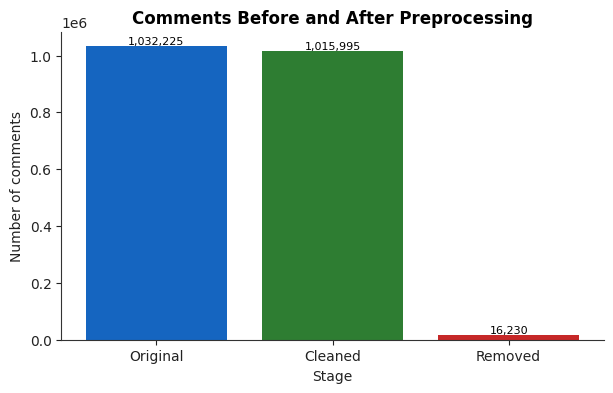

In [8]:
raw_count_for_plot = rawCommentsRDD.count()
clean_count_for_plot = cleanCommentsRDD.count()
removed_count_for_plot = raw_count_for_plot - clean_count_for_plot
preprocessing_plot_df = pd.DataFrame({
    "stage": ["Original", "Cleaned", "Removed"],
    "comments": [raw_count_for_plot, clean_count_for_plot, removed_count_for_plot],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(preprocessing_plot_df["stage"], preprocessing_plot_df["comments"], color=["#1565C0", "#2E7D32", "#C62828"])
ax.set_title("Comments Before and After Preprocessing")
ax.set_xlabel("Stage")
ax.set_ylabel("Number of comments")
for i, value in enumerate(preprocessing_plot_df["comments"]):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
show_eda_plot(fig)

### 5.1 Save Processed Data

Store cleaned dataset as Parquet for downstream analysis and model training.

In [9]:
PROCESSED_PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)

(
    clean_df
    .write
    .mode("overwrite")
    .parquet(str(PROCESSED_PARQUET_PATH))
)

print(f"Processed data saved at: {PROCESSED_PARQUET_PATH}")

Processed data saved at: /Users/pedro/Documents/DSAA/2semester/BDA/Project/Big-Data-Analyitics-Project/data/processed/youtube-comments-clean.parquet


## 6. Sentiment Analysis

### 6.1 Sentiment Distribution

Analyze the balance and distribution of sentiment classes in the dataset.

In [10]:
total_rows = clean_df.count()

sentiment_dist = (
    clean_df
    .groupBy("Sentiment")
    .count()
    .withColumn("percentage", F.round((F.col("count") / total_rows) * 100, 2))
    .orderBy(F.desc("count"))
)

sentiment_dist.show()

+---------+------+----------+
|Sentiment| count|percentage|
+---------+------+----------+
| Negative|344105|     33.87|
|  Neutral|336475|     33.12|
| Positive|335415|     33.01|
+---------+------+----------+



What is the percentage distribution of sentiment?

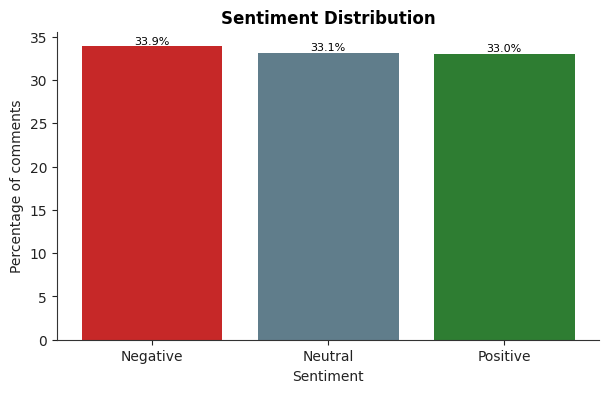

In [11]:
# (!) BIG-DATA NOTE: .toPandas() is safe here because sentiment_dist is the
# result of a GROUP BY on the Sentiment column, which has exactly 3 distinct
# values (Positive, Neutral, Negative). The collected result is always 3 rows,
# independent of the total number of comments in the dataset.
sentiment_plot_df = sentiment_dist.toPandas().sort_values("percentage", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    sentiment_plot_df["Sentiment"],
    sentiment_plot_df["percentage"],
    color=[SENTIMENT_COLORS.get(sentiment, "#1565C0") for sentiment in sentiment_plot_df["Sentiment"]],
)
ax.set_title("Sentiment Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Percentage of comments")
for i, value in enumerate(sentiment_plot_df["percentage"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
show_eda_plot(fig)

### 6.2 Sentiment Distribution by countries

Analyze the balance and distribution of sentiment classes in the dataset.

In [12]:
country_df = (
    clean_df
    .withColumn(
        "CountryCode",
        F.when(
            F.col("CountryCode").isNull() | (F.trim(F.col("CountryCode")) == ""),
            "Unknown"
        ).otherwise(F.col("CountryCode"))
    )
)

(
    country_df
    .groupBy("CountryCode")
    .count()
    .orderBy(F.desc("count"))
    .show(10)
)

+-----------+------+
|CountryCode| count|
+-----------+------+
|         US|317633|
|         AU|138671|
|         GB|128135|
|         IN|119372|
|         CA|116158|
|         IE| 72504|
|         NZ| 69116|
|         DE| 37479|
|         PH| 16927|
+-----------+------+



Which countries have the highest number of comments?

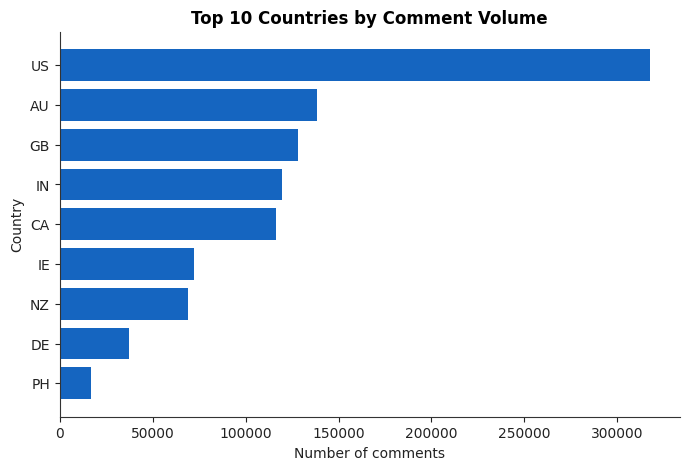

In [13]:
# (!) BIG-DATA NOTE: .toPandas() is safe here because .limit(10) is applied
# upstream inside Spark, so at most 10 rows are transferred to the driver.
# Note: .limit() on a large dataset can be slow without a preceding .orderBy(),
# but since the orderBy is already applied before limit, partition pruning works
# correctly and only the top 10 rows are materialised on the driver.
country_plot_df = (
    country_df
    .groupBy("CountryCode")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
    .toPandas()
    .sort_values("count", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(country_plot_df["CountryCode"], country_plot_df["count"], color="#1565C0")
ax.set_title("Top 10 Countries by Comment Volume")
ax.set_xlabel("Number of comments")
ax.set_ylabel("Country")
ax.spines[["top", "right"]].set_visible(False)
show_eda_plot(fig)

### 6.3 Engagement by Sentiment

Understand how user engagement (likes, replies) varies across different sentiment classes.

In [14]:
(
    clean_df
    .groupBy("Sentiment")
    .agg(
        F.count("*").alias("total_comments"),
        F.round(F.avg("Likes"), 2).alias("avg_likes"),
        F.round(F.avg("Replies"), 2).alias("avg_replies"),
        F.max("Likes").alias("max_likes"),
        F.max("Replies").alias("max_replies")
    )
    .orderBy(F.desc("total_comments"))
    .show()
)

+---------+--------------+---------+-----------+---------+-----------+
|Sentiment|total_comments|avg_likes|avg_replies|max_likes|max_replies|
+---------+--------------+---------+-----------+---------+-----------+
| Negative|        344105|    55.08|        2.0|   275849|        750|
|  Neutral|        336475|   103.96|       1.77|   217740|        751|
| Positive|        335415|   152.03|        2.4|   193734|        751|
+---------+--------------+---------+-----------+---------+-----------+



How does average engagement change by sentiment?

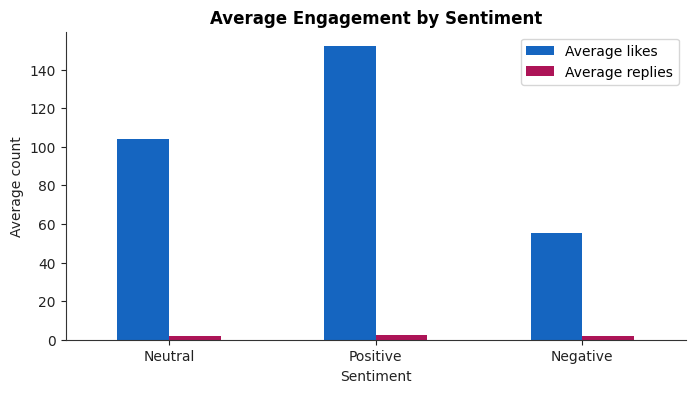

In [15]:
# (!) BIG-DATA NOTE: .toPandas() is safe here because the upstream groupBy
# on 'Sentiment' reduces the DataFrame to exactly 3 rows before collection.
# pandas is used only for the matplotlib chart; all aggregation is done in Spark.
engagement_plot_df = (
    clean_df
    .groupBy("Sentiment")
    .agg(
        F.round(F.avg("Likes"), 2).alias("avg_likes"),
        F.round(F.avg("Replies"), 2).alias("avg_replies"),
    )
    .toPandas()
)
engagement_plot_df = engagement_plot_df.set_index("Sentiment")[["avg_likes", "avg_replies"]]

fig, ax = plt.subplots(figsize=(8, 4))
engagement_plot_df.plot(kind="bar", ax=ax, color=["#1565C0", "#AD1457"])
ax.set_title("Average Engagement by Sentiment")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Average count")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Average likes", "Average replies"])
ax.spines[["top", "right"]].set_visible(False)
show_eda_plot(fig)

## 7. Spark SQL Analysis

The same distributed data can be queried with standard SQL using a temporary view.

This section demonstrates Spark SQL as a complement to the DataFrame API: both approaches produce identical execution plans -> the SQL parser is just an alternative frontend to the Catalyst optimiser.

Queries covered:
1. Sentiment summary with percentage via `CROSS JOIN` subquery (big-data-safe alternative to `OVER ()`).
2. Sentiment dominance per engagement tier.
3. Top-3 highest-liked comments per sentiment using `ROW_NUMBER()`.
4. Country x sentiment cross-analysis using a `JOIN` with a subquery.

In [16]:
# Register the cleaned DataFrame as a session-scoped temporary SQL view.
# The view is never written to disk and disappears when the Spark session ends.
# All queries below run on the same distributed partitions as the DataFrame API.
clean_df.createOrReplaceTempView("comments")
print("Temporary view 'comments' registered.")
spark.sql("DESCRIBE comments").show(truncate=False)

Temporary view 'comments' registered.
+------------------+---------+-------+
|col_name          |data_type|comment|
+------------------+---------+-------+
|CommentID         |string   |NULL   |
|VideoID           |string   |NULL   |
|VideoTitle        |string   |NULL   |
|AuthorName        |string   |NULL   |
|AuthorChannelID   |string   |NULL   |
|CommentText       |string   |NULL   |
|Sentiment         |string   |NULL   |
|Likes             |int      |NULL   |
|Replies           |int      |NULL   |
|PublishedAt       |string   |NULL   |
|CountryCode       |string   |NULL   |
|CategoryID        |bigint   |NULL   |
|clean_text        |string   |NULL   |
|comment_word_count|int      |NULL   |
|comment_char_count|int      |NULL   |
|engagement_total  |int      |NULL   |
|engagement_level  |string   |NULL   |
+------------------+---------+-------+



### 7.1 Query 1 - Sentiment summary with percentage

Reproduces the groupBy aggregation from the DataFrame section and adds a `pct_of_total` column calculated via a `CROSS JOIN` with a single-row subquery.

> **(!) BIG-DATA NOTE:** the natural SQL idiom for a global percentage is `SUM(COUNT(*)) OVER ()` - a window function with no `PARTITION BY`. Spark warns at runtime (*"No Partition Defined for Window operation"*) because this forces all data onto a single partition, which would be catastrophic at true scale. The `CROSS JOIN` pattern avoids that shuffle entirely: it joins 3 aggregated rows gainst 1 scalar row, which Spark optimises as a broadcast join automatically.

In [17]:
spark.sql("""
    SELECT
        s.Sentiment,
        s.total_comments,
        s.avg_likes,
        s.avg_replies,
        s.max_likes,
        ROUND(s.total_comments * 100.0 / t.grand_total, 2)  AS pct_of_total
    FROM (
        SELECT
            Sentiment,
            COUNT(*)                AS total_comments,
            ROUND(AVG(Likes),   2)  AS avg_likes,
            ROUND(AVG(Replies), 2)  AS avg_replies,
            MAX(Likes)              AS max_likes
        FROM comments
        GROUP BY Sentiment
    ) s
    CROSS JOIN (
        SELECT COUNT(*) AS grand_total FROM comments
    ) t
    ORDER BY s.total_comments DESC
""").show()

+---------+--------------+---------+-----------+---------+------------+
|Sentiment|total_comments|avg_likes|avg_replies|max_likes|pct_of_total|
+---------+--------------+---------+-----------+---------+------------+
| Negative|        344105|    55.08|        2.0|   275849|       33.87|
|  Neutral|        336475|   103.96|       1.77|   217740|       33.12|
| Positive|        335415|   152.03|        2.4|   193734|       33.01|
+---------+--------------+---------+-----------+---------+------------+



### 7.2 Query 2 - Sentiment dominance per engagement tier

For each engagement level, ranks sentiment classes by comment volume and shows what percentage of that tier each sentiment represents.
This answers a concrete business question: *among the comments that attract the most attention, which sentiment dominates?*

In [18]:
spark.sql("""
    SELECT
        engagement_level,
        Sentiment,
        COUNT(*) AS num_comments,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (
                PARTITION BY engagement_level
            ),
            1
        ) AS pct_within_level,
        RANK() OVER (
            PARTITION BY engagement_level
            ORDER BY COUNT(*) DESC
        ) AS rank_within_level
    FROM comments
    GROUP BY engagement_level, Sentiment
    ORDER BY engagement_level, rank_within_level
""").show(20)

+----------------+---------+------------+----------------+-----------------+
|engagement_level|Sentiment|num_comments|pct_within_level|rank_within_level|
+----------------+---------+------------+----------------+-----------------+
|            high| Positive|       64505|            48.7|                1|
|            high| Negative|       35986|            27.2|                2|
|            high|  Neutral|       31898|            24.1|                3|
|             low| Positive|       72056|            41.3|                1|
|             low|  Neutral|       56462|            32.3|                2|
|             low| Negative|       46052|            26.4|                3|
|          medium| Positive|       40871|            47.7|                1|
|          medium| Negative|       22480|            26.2|                2|
|          medium|  Neutral|       22391|            26.1|                3|
|            none| Negative|      239587|            38.4|                1|

### 7.3 Query 3 - Top 3 most-liked comments per sentiment

Uses `ROW_NUMBER()` inside a subquery to rank comments by likes within each sentiment class, then filters to the top 3. This pattern is the SQL equivalent of the window function used earlier in the DataFrame word-frequency section.

In [19]:
spark.sql("""
    SELECT Sentiment, CommentText, Likes, Replies
    FROM (
        SELECT
            Sentiment,
            CommentText,
            Likes,
            Replies,
            ROW_NUMBER() OVER (
                PARTITION BY Sentiment
                ORDER BY Likes DESC
            ) AS rank_in_sentiment
        FROM comments
        WHERE Likes > 0
    )
    WHERE rank_in_sentiment <= 3
    ORDER BY Sentiment, rank_in_sentiment
""").show(truncate=80)

+---------+--------------------------------------------------------------------------------+------+-------+
|Sentiment|                                                                     CommentText| Likes|Replies|
+---------+--------------------------------------------------------------------------------+------+-------+
| Negative|All she had to do was run another 20 yards and the guy would have went into c...|275849|    720|
| Negative|"You know what's worse than USELESS? USELESS and OBLIVIOUS"\nTruer words have...|135340|    103|
| Negative|They took a service animal from a woman in need of her alert dog. That would ...|125584|    750|
|  Neutral|This makes me regret not watching this on live TV. Shoutout to the 17 people ...|217740|    408|
|  Neutral|                      House thinking “god every one of you would have killed me”|201768|     80|
|  Neutral|                            People in that area the next day:\n\n"It was aliens"|178248|    318|
| Positive|Amazing thing abo

### 7.4 Query 4 - Country x sentiment cross-analysis (JOIN with subquery)

Identifies the top 5 countries by total comment volume using a subquery, then joins back to the full table to break down each country's sentiment distribution. This demonstrates a Spark SQL `JOIN` producing a cross-dimensional view relevant to the client question: *which markets are most positive or negative?*

In [ ]:
spark.sql("""
    SELECT
        top5.CountryCode,
        c.Sentiment,
        COUNT(*) AS comment_count,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (
                PARTITION BY top5.CountryCode
            ),
            1
        ) AS pct_within_country
    FROM comments c
    INNER JOIN (
        SELECT CountryCode
        FROM   comments
        WHERE  CountryCode != 'Unknown'
        GROUP  BY CountryCode
        ORDER  BY COUNT(*) DESC, CountryCode ASC
        LIMIT  5
    ) top5 ON c.CountryCode = top5.CountryCode
    GROUP BY top5.CountryCode, c.Sentiment
    ORDER BY CountryCode, comment_count DESC
""").show(30)

+-----------+---------+-------------+------------------+
|CountryCode|Sentiment|comment_count|pct_within_country|
+-----------+---------+-------------+------------------+
|         AU| Negative|        50295|              36.3|
|         AU| Positive|        44400|              32.0|
|         AU|  Neutral|        43976|              31.7|
|         CA| Negative|        43331|              37.3|
|         CA| Positive|        39480|              34.0|
|         CA|  Neutral|        33347|              28.7|
|         GB| Negative|        49292|              38.5|
|         GB|  Neutral|        42773|              33.4|
|         GB| Positive|        36070|              28.1|
|         IN|  Neutral|        50117|              42.0|
|         IN| Positive|        49738|              41.7|
|         IN| Negative|        19517|              16.3|
|         US| Positive|       108127|              34.0|
|         US| Negative|       107313|              33.8|
|         US|  Neutral|       1

## 8. Text Mining

Analyze word patterns and term frequency in comments using Spark RDDs.

In [21]:


word_counts_rdd = (
    clean_df
    .select("clean_text")  # selects only the column with the cleaned text
    .rdd  # converts the DataFrame into an RDD
    .flatMap(lambda row: row["clean_text"].split())  # splits each text into words and flattens everything into one sequence
    .map(lambda word: word.strip())  # removes extra spaces before and after each word
    .filter(lambda word: len(word) > 2)  # keeps only words with more than 2 characters
    .filter(lambda word: word not in STOP_WORDS)  # removes common words from the stop words list
    .map(lambda word: (word, 1))  # transforms each word into a pair like (word, 1)
    .reduceByKey(lambda a, b: a + b)  # sums the counts for each repeated word
)

top_words = word_counts_rdd.takeOrdered(20, key=lambda x: -x[1])

print("Top 20 most frequent words:")
for word, count in top_words:
    print(f"{word}: {count}")

Top 20 most frequent words:
people: 56850
video: 55502
thank: 44724
now: 37736
love: 37299
time: 36870
good: 36759
thanks: 33830
know: 33071
great: 32435
because: 31955
these: 30248
only: 30245
way: 29316
sir: 29009
please: 28162
been: 27468
need: 27448
then: 26865
see: 26129


Which words appear most frequently in the comments?

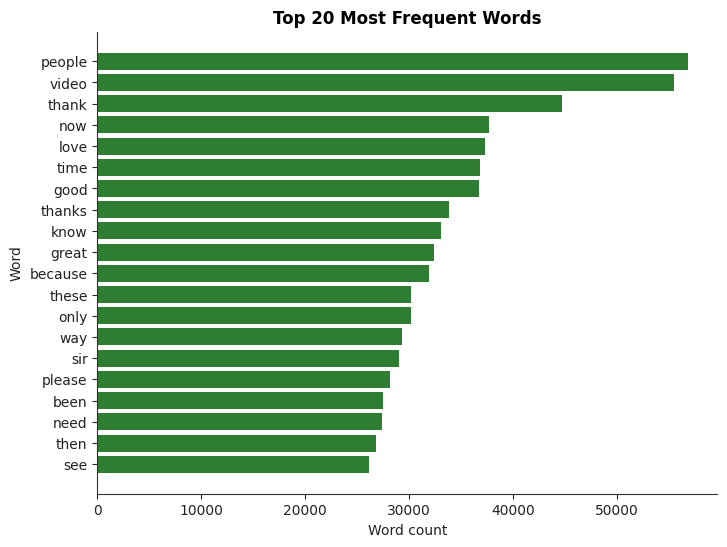

In [22]:
top_words_plot_df = pd.DataFrame(top_words, columns=["word", "count"]).sort_values("count", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_words_plot_df["word"], top_words_plot_df["count"], color="#2E7D32")
ax.set_title("Top 20 Most Frequent Words")
ax.set_xlabel("Word count")
ax.set_ylabel("Word")
ax.spines[["top", "right"]].set_visible(False)
show_eda_plot(fig)

### Word Frequency by Sentiment

Identify which words are more frequent in positive, neutral or negative comments.

In [23]:
top_words_by_sentiment = (
    clean_df
    .select(
        "Sentiment",
        F.explode(F.split(F.col("clean_text"), " ")).alias("word")
    )
    .filter(F.length("word") > 2)
    .filter(~F.col("word").isin(STOP_WORDS))
    .groupBy("Sentiment", "word")
    .count()
)

window_spec = Window.partitionBy("Sentiment").orderBy(F.desc("count"))

top_words_by_sentiment = (
    top_words_by_sentiment
    .withColumn("rank", F.row_number().over(window_spec))
    .filter(F.col("rank") <= 10)
    .orderBy("Sentiment", "rank")
)

top_words_by_sentiment.show(50, truncate=False)

+---------+-------+-----+----+
|Sentiment|word   |count|rank|
+---------+-------+-----+----+
|Negative |people |29104|1   |
|Negative |because|15744|2   |
|Negative |now    |14225|3   |
|Negative |these  |14117|4   |
|Negative |only   |13744|5   |
|Negative |time   |13045|6   |
|Negative |trump  |12874|7   |
|Negative |then   |11982|8   |
|Negative |know   |11767|9   |
|Negative |video  |11574|10  |
|Neutral  |video  |15849|1   |
|Neutral  |please |13210|2   |
|Neutral  |people |11477|3   |
|Neutral  |know   |11355|4   |
|Neutral  |use    |10015|5   |
|Neutral  |sir    |9852 |6   |
|Neutral  |time   |9837 |7   |
|Neutral  |now    |9588 |8   |
|Neutral  |could  |9458 |9   |
|Neutral  |only   |8661 |10  |
|Positive |thank  |38889|1   |
|Positive |love   |28910|2   |
|Positive |video  |28079|3   |
|Positive |thanks |26414|4   |
|Positive |great  |23656|5   |
|Positive |good   |21112|6   |
|Positive |best   |18736|7   |
|Positive |people |16269|8   |
|Positive |sir    |15835|9   |
|Positiv

Which words are most frequent in each sentiment?

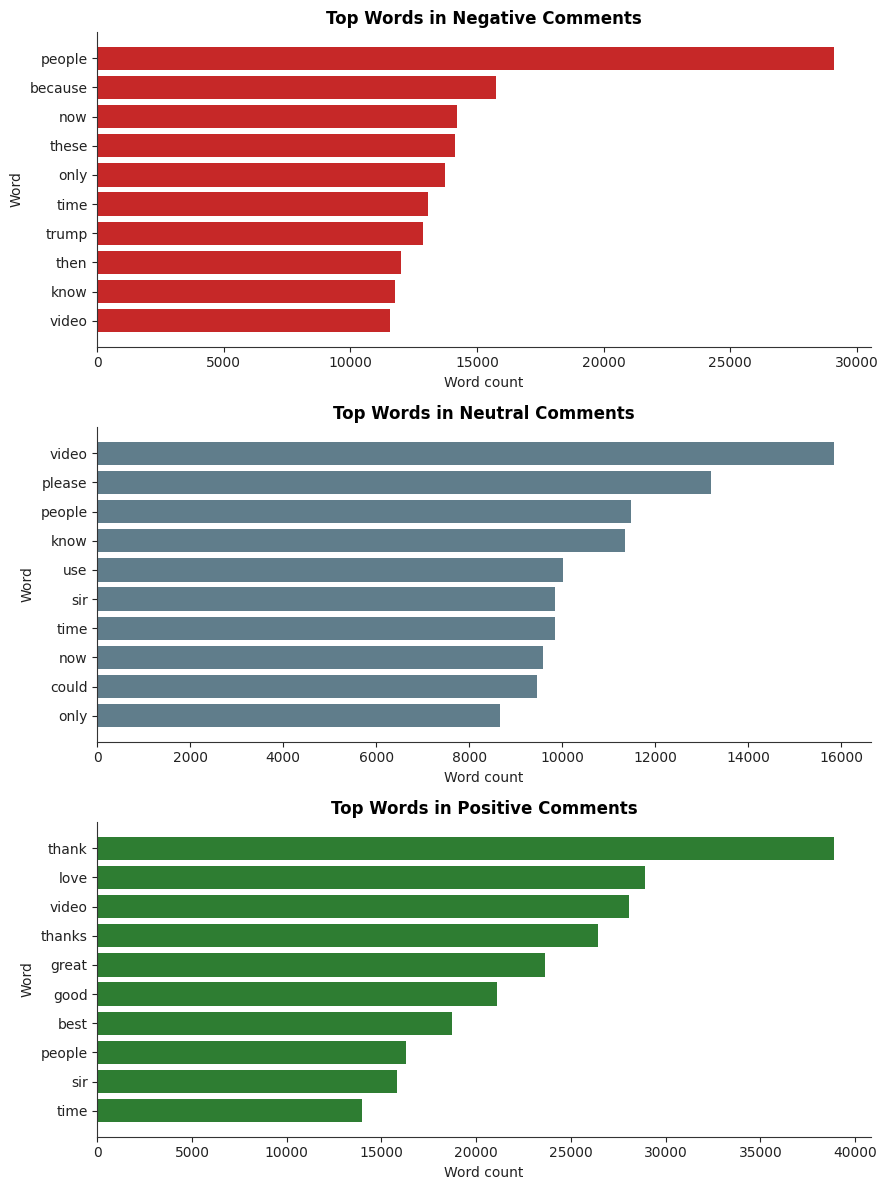

In [24]:
# (!) BIG-DATA NOTE: .toPandas() is safe here because top_words_by_sentiment
# was filtered to rank <= 10 per sentiment class. With 3 sentiment classes the
# maximum number of rows collected to the driver is 30, regardless of how many
# comments or unique words exist in the full dataset.
top_words_sentiment_plot_df = top_words_by_sentiment.toPandas()
sentiments = sorted(top_words_sentiment_plot_df["Sentiment"].unique())

fig, axes = plt.subplots(len(sentiments), 1, figsize=(9, 4 * len(sentiments)))
if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sentiments):
    subset = (
        top_words_sentiment_plot_df[top_words_sentiment_plot_df["Sentiment"] == sentiment]
        .sort_values("count", ascending=True)
    )
    ax.barh(subset["word"], subset["count"], color=SENTIMENT_COLORS.get(sentiment, "#1565C0"))
    ax.set_title(f"Top Words in {sentiment} Comments")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Word")
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
show_eda_plot(fig)